<a href="https://colab.research.google.com/github/DanielGrahamB/pqc-research/blob/subband/PQC_MIMO_Simulations_subband.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Configuration and Imports

In [55]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Set random seed for reproducibility
sionna.phy.config.seed = 20


In [56]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import time
import random

# forced double precision for security precision requirements
torch.set_default_dtype(torch.float64)

from sionna.phy import Block
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, \
                            LSChannelEstimator, LMMSEEqualizer, \
                            RemoveNulledSubcarriers
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, UMi, UMa, RMa
from sionna.phy.channel import gen_single_sector_topology as gen_topology
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel, \
                               ApplyOFDMChannel, OFDMChannel
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, BinarySource, QAMSource
from sionna.phy.utils import ebnodb2no, sim_ber, compute_ber
from sionna.phy.ofdm import ZFEqualizer

# import corrected lattice utilities from your local file
from lattice import LatticeBasedEncryptor, qam16_lattice_to_normalized, qam16_slicer_lattice

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

def compute_bler(b, b_hat):
    # determining block errors by checking if any bit in a block is incorrect
    errors = torch.not_equal(b, b_hat)
    # reducing over the last dimension to find blocks with at least one error
    block_errors = torch.any(errors, dim=-1)
    # calculating the mean to get the block error rate
    return torch.mean(block_errors.to(torch.float64))

## System Setup

We will now configure all components of the system model step-by-step.

In [57]:
scenario = "umi"
carrier_frequency = 3.5e9 # C-band range mostly used for 5G-NR (New Radio)
direction = "uplink" # realism implies from UE (user-equipment) to Base Station
num_ut = 4 # num of user terminals (transmitters)
batch_size = 32

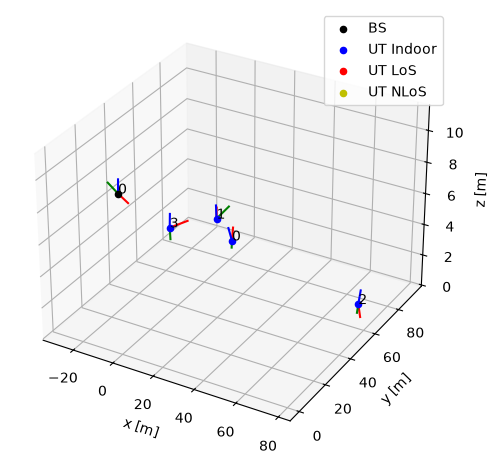

In [58]:
# Define the UT antenna array
ut_array = Antenna(polarization="single",
                   polarization_type="V",
                   antenna_pattern="omni",
                   carrier_frequency=carrier_frequency)

# Define the BS antenna array
bs_array = AntennaArray(num_rows=1,
                        num_cols=4,
                        polarization="dual",
                        polarization_type="VH",
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)

# Create channel model
channel_model = UMi(carrier_frequency=carrier_frequency,
                    o2i_model="low",
                    ut_array=ut_array,
                    bs_array=bs_array,
                    direction=direction,
                    enable_pathloss=False,
                    enable_shadow_fading=False)

# Generate the topology
topology = gen_topology(batch_size, num_ut, scenario)

# Set the topology
channel_model.set_topology(*topology)

# Visualize the topology
channel_model.show_topology()

In [59]:
# The number of transmitted streams is equal to the number of UT antennas
num_streams_per_tx = 1

# Create an RX-TX association matrix
# rx_tx_association[i,j]=1 means that receiver i gets at least one stream
# from transmitter j. Depending on the transmission direction (uplink or downlink),
# the role of UT and BS can change. However, as we have only a single
# transmitter and receiver, this does not matter:
rx_tx_association = np.zeros([1, num_ut])
rx_tx_association[0, :] = 1

# Instantiate a StreamManagement object
# This determines which data streams are determined for which receiver.
# In this simple setup, this is fairly simple. However, it can get complicated
# for simulations with many transmitters and receivers.
sm = StreamManagement(rx_tx_association, num_streams_per_tx)

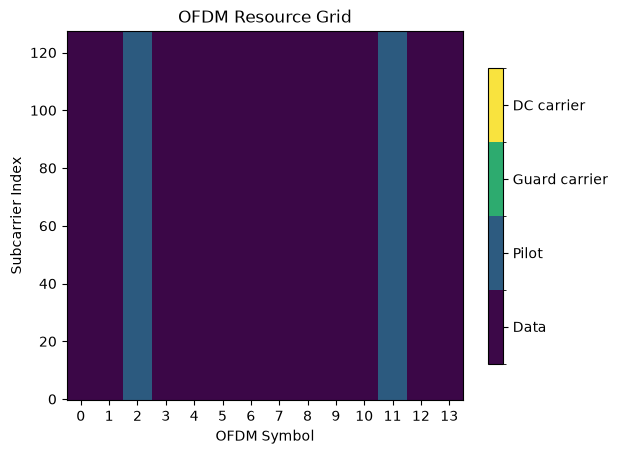

In [60]:
rg = ResourceGrid(num_ofdm_symbols=14,
                  fft_size=128,
                  subcarrier_spacing=30e3,
                  num_tx=num_ut,
                  num_streams_per_tx=num_streams_per_tx,
                  cyclic_prefix_length=20,
                  pilot_pattern="kronecker",
                  pilot_ofdm_symbol_indices=[2,11])
rg.show();

In [61]:
num_bits_per_symbol = 2 # QPSK modulation
coderate = 0.5 # The code rate
n = int(rg.num_data_symbols*num_bits_per_symbol) # Number of coded bits
k = int(n*coderate) # Number of information bits

# The binary source will create batches of information bits
binary_source = BinarySource()
qam_source = QAMSource(num_bits_per_symbol)

# The encoder maps information bits to coded bits
encoder = LDPC5GEncoder(k, n)

# The mapper maps blocks of information bits to constellation symbols
mapper = Mapper("qam", num_bits_per_symbol)

# The resource grid mapper maps symbols onto an OFDM resource grid
rg_mapper = ResourceGridMapper(rg)

# This function removes nulled subcarriers from any tensor having the shape of a resource grid
remove_nulled_scs = RemoveNulledSubcarriers(rg)

# The LS channel estimator will provide channel estimates and error variances
ls_est = LSChannelEstimator(rg, interpolation_type="nn")

# The LMMSE equalizer will provide soft symbols together with noise variance estimates
lmmse_equ = LMMSEEqualizer(rg, sm)

# The demapper produces LLR for all coded bits
demapper = Demapper("app", "qam", num_bits_per_symbol)

# The decoder provides hard-decisions on the information bits
decoder = LDPC5GDecoder(encoder, hard_out=True)

# OFDM CHannel
ofdm_channel = OFDMChannel(channel_model, rg, add_awgn=True, normalize_channel=False, return_channel=True)
channel_freq = ApplyOFDMChannel(add_awgn=True)
frequencies = subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)

## Uplink Transmissions in the Frequency Domain

We now simulate a batch of uplink transmissions. We keep references to the estimated and actual channel frequency responses.

In [62]:
ebno_db = 10
no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate, rg)
b = binary_source([batch_size, num_ut, rg.num_streams_per_tx, encoder.k])
c = encoder(b)
x = mapper(c)
x_rg = rg_mapper(x)

a, tau = channel_model(num_time_samples=rg.num_ofdm_symbols, sampling_frequency=1/rg.ofdm_symbol_duration)
h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)

y = channel_freq(x_rg, h_freq, no)
h_hat, err_var = ls_est (y, no)
x_hat, no_eff = lmmse_equ(y, h_hat, err_var, no)
llr = demapper(x_hat, no_eff)
b_hat = decoder(llr)
print("BER: {}".format(compute_ber(b, b_hat).cpu().numpy()))

BER: 0.0


### Compare Estimated and Actual Frequency Responses
We can now compare the estimated frequency responses and ground truth:

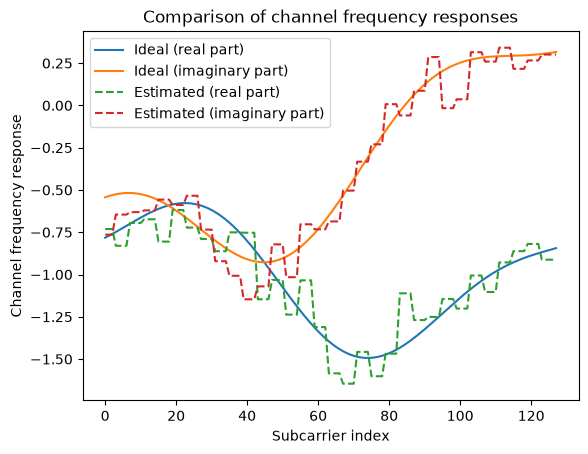

In [63]:
# In the example above, we assumed perfect CSI, i.e.,
# h_hat correpsond to the exact ideal channel frequency response.
h_perf = remove_nulled_scs(h_freq)[0,0,0,0,0,0]

# We now compute the LS channel estimate from the pilots.
h_est = h_hat[0,0,0,0,0,0]

plt.figure()
plt.plot(np.real(h_perf.cpu()))
plt.plot(np.imag(h_perf.cpu()))
plt.plot(np.real(h_est.cpu()), "--")
plt.plot(np.imag(h_est.cpu()), "--")
plt.xlabel("Subcarrier index")
plt.ylabel("Channel frequency response")
plt.legend(["Ideal (real part)", "Ideal (imaginary part)", "Estimated (real part)", "Estimated (imaginary part)"]);
plt.title("Comparison of channel frequency responses");

### Understand the Difference Between the Channel Models
Before we proceed with more advanced simulations, it is important to understand the differences
between the UMi, UMa, and RMa models. In the following code snippet, we compute the empirical cummulative
distribution function (CDF) of the condition number of the channel frequency response matrix
between all receiver and transmit antennas.

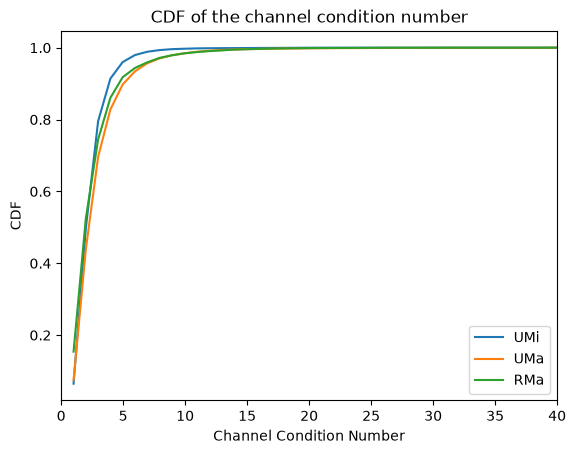

In [64]:
def cond_hist(scenario):
    """Generates a histogram of the channel condition numbers"""

    # Setup a CIR generator
    if scenario == "umi":
        channel_model = UMi(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "uma":
        channel_model = UMa(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "rma":
        channel_model = RMa(carrier_frequency=carrier_frequency,
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)

    topology = gen_topology(1024, num_ut, scenario)

    # Set the topology
    channel_model.set_topology(*topology)

    # Generate random CIR realizations
    # As we nned only a single sample in time, the sampling_frequency
    # does not matter.
    cir = channel_model(1, 1)

    # Compute the frequency response
    h = cir_to_ofdm_channel(frequencies, *cir, normalize=True)

    h = torch.squeeze(h)
    h = torch.permute(h, (0, 3, 1, 2))

    # Compute condition number
    c = np.reshape(np.linalg.cond(h.cpu().numpy()), [-1])

    # Compute normalized histogram
    hist, bins = np.histogram(c, 100, (1, 100))
    hist = hist/np.sum(hist)
    return bins[:-1], hist

plt.figure()
for cdl_model in ["umi", "uma", "rma"]:
    bins, hist = cond_hist(cdl_model)
    plt.plot(bins, np.cumsum(hist))
plt.xlim([0,40])
plt.legend(["UMi", "UMa", "RMa"]);
plt.xlabel("Channel Condition Number")
plt.ylabel("CDF")
plt.title("CDF of the channel condition number");

From the figure above, you can observe that the UMi and UMa models
are better conditioned than the RMa model. This makes
them more suitable for MIMO transmissions as we will observe in the next
section.

It is also interesting to look at the channel frequency responses of these different models, as done in the next cell:

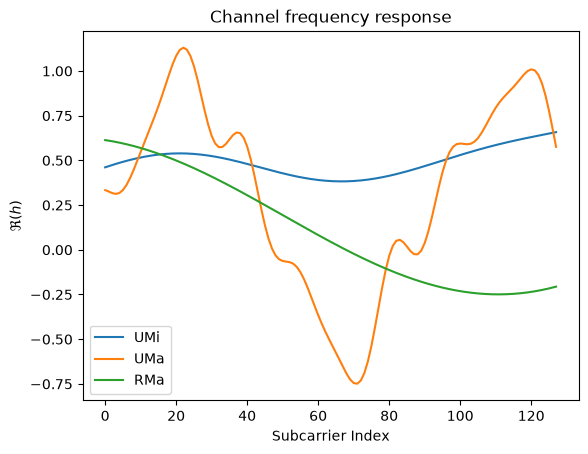

In [65]:
def freq_response(scenario):
    """Generates an example frequency response"""

    # Setup a CIR generator
    if scenario == "umi":
        channel_model = UMi(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "uma":
        channel_model = UMa(carrier_frequency=carrier_frequency,
                                      o2i_model="low",
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)
    elif scenario == "rma":
        channel_model = RMa(carrier_frequency=carrier_frequency,
                                      ut_array=ut_array,
                                      bs_array=bs_array,
                                      direction="uplink",
                                      enable_pathloss=False,
                                      enable_shadow_fading=False)

    topology = gen_topology(1, num_ut, scenario)

    # Set the topology
    channel_model.set_topology(*topology)

    # Generate random CIR realizations
    # As we nned only a single sample in time, the sampling_frequency
    # does not matter.
    cir = channel_model(1, 1)

    # Compute the frequency response
    h = cir_to_ofdm_channel(frequencies, *cir, normalize=True)
    h = h.squeeze()

    return h[0,0]

plt.figure()
for cdl_model in ["umi", "uma", "rma"]:
    h = freq_response(cdl_model)
    plt.plot(np.real(h.cpu()))
plt.legend(["UMi", "UMa", "RMa"]);
plt.xlabel("Subcarrier Index")
plt.ylabel(r"$\Re(h)$")
plt.title("Channel frequency response");

The RMa model has significantly less frequency selectivity than the other models which makes channel estimation easier.

### Setup a Sionna Block for BER simulations

In [66]:
class Model(Block):
    def __init__(self, scenario, perfect_csi=True, interpolation_type="nn"):
        super().__init__()
        self._scenario = scenario
        self._perfect_csi = perfect_csi
        self._carrier_frequency = 3.5e9
        self._fft_size = 128
        self._subcarrier_spacing = 30e3
        self._num_ofdm_symbols = 14
        self._cyclic_prefix_length = 20
        self._pilot_ofdm_symbol_indices = [2, 11]
        self._num_bs_ant = 8
        self._num_ut = 4
        self._num_ut_ant = 1
        self._num_bits_per_symbol = 4
        self._coderate = 1.0
        self._lattice_n = 512

        self._lattice_engine = LatticeBasedEncryptor(n=self._lattice_n, verbose=False)

        bs_ut_association = np.zeros([1, self._num_ut])
        bs_ut_association[0, :] = 1
        self._rx_tx_association = bs_ut_association
        self._num_tx = self._num_ut
        self._num_streams_per_tx = self._num_ut_ant

        self._rg = ResourceGrid(num_ofdm_symbols=self._num_ofdm_symbols,
                                fft_size=self._fft_size,
                                subcarrier_spacing=self._subcarrier_spacing,
                                num_tx=self._num_tx,
                                num_streams_per_tx=self._num_streams_per_tx,
                                cyclic_prefix_length=self._cyclic_prefix_length,
                                pilot_pattern="kronecker",
                                pilot_ofdm_symbol_indices=self._pilot_ofdm_symbol_indices)

        self._sm = StreamManagement(self._rx_tx_association, self._num_streams_per_tx)

        self._ut_array = AntennaArray(num_rows=1, num_cols=1, polarization="single",
                                      polarization_type="V", antenna_pattern="omni",
                                      carrier_frequency=self._carrier_frequency)

        self._bs_array = AntennaArray(num_rows=1, num_cols=int(self._num_bs_ant/2),
                                      polarization="dual", polarization_type="cross",
                                      antenna_pattern="38.901", carrier_frequency=self._carrier_frequency)

        if self._scenario == "umi":
            self._channel_model = UMi(carrier_frequency=self._carrier_frequency, o2i_model="low",
                                      ut_array=self._ut_array, bs_array=self._bs_array,
                                      direction="uplink", enable_pathloss=False, enable_shadow_fading=False)
        elif self._scenario == "uma":
            self._channel_model = UMa(carrier_frequency=self._carrier_frequency, o2i_model="low",
                                      ut_array=self._ut_array, bs_array=self._bs_array,
                                      direction="uplink", enable_pathloss=False, enable_shadow_fading=False)
        elif self._scenario == "rma":
            self._channel_model = RMa(carrier_frequency=self._carrier_frequency, ut_array=self._ut_array,
                                      bs_array=self._bs_array, direction="uplink",
                                      enable_pathloss=False, enable_shadow_fading=False)

        self._binary_source = BinarySource()
        self._k = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        self._mapper = Mapper("qam", self._num_bits_per_symbol, dtype=torch.complex128)
        self._rg_mapper = ResourceGridMapper(self._rg, dtype=torch.complex128)

        self._ofdm_channel = OFDMChannel(self._channel_model, self._rg, add_awgn=True,
                                         normalize_channel=True, return_channel=True, dtype=torch.complex128)
        self._remove_nulled_subcarriers = RemoveNulledSubcarriers(self._rg, dtype=torch.complex128)
        self._ls_est = LSChannelEstimator(self._rg, interpolation_type=interpolation_type, dtype=torch.complex128)
        self._lmmse_equ = LMMSEEqualizer(self._rg, self._sm, dtype=torch.complex128)
        self._demapper = Demapper("app", "qam", self._num_bits_per_symbol, dtype=torch.float64)

    def babai_decode_internal(self, x_hat_reshaped):
        device = x_hat_reshaped.device
        x_input = x_hat_reshaped.to(dtype=torch.complex128)
        R = self._lattice_engine.R.to(device=device, dtype=torch.complex128)
        R_inv = torch.linalg.pinv(R)
        B_inv = self._lattice_engine.B_inv.to(device=device, dtype=torch.complex128)

        Y = torch.matmul(x_input, R_inv.T)
        Y_integer = torch.round(Y.real) + 1j * torch.round(Y.imag)

        lattice_point = torch.matmul(Y_integer, R.T)
        S_hat = torch.matmul(lattice_point, B_inv.T)
        return S_hat

    def new_topology(self, batch_size):
        self._channel_model.reset_topology()
        topology = gen_topology(batch_size, self._num_ut, self._scenario, min_ut_velocity=0.0, max_ut_velocity=0.0)
        self._channel_model.set_topology(*topology)

    def call(self, batch_size, ebno_db):
        self.new_topology(batch_size)
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)
        b = self._binary_source([batch_size, self._num_tx, self._num_streams_per_tx, self._k])

        x = self._mapper(b)
        x_shape = x.shape
        x_reshaped = torch.reshape(x, (-1, self._lattice_n))
        self._lattice_engine.B = self._lattice_engine.B.to(device=x.device, dtype=torch.complex128)
        qs = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x.device))
        x_enc_blocks = self._lattice_engine.encrypt(x_reshaped.to(torch.complex128) * qs) / qs
        x_enc = torch.reshape(x_enc_blocks, x_shape)

        x_rg = self._rg_mapper(x_enc)
        y, h = self._ofdm_channel(x_rg, no)

        if self._perfect_csi:
            h_hat = self._remove_nulled_subcarriers(h)
            err_var = torch.tensor(0.0, dtype=torch.complex128, device=y.device)
        else:
            h_hat, err_var = self._ls_est(y, no)

        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)

        qam_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x_hat.device))
        x_hat_lattice_domain = x_hat * qam_scale

        x_hat_shape = x_hat.shape
        x_hat_reshaped = torch.reshape(x_hat_lattice_domain, (-1, self._lattice_n))
        x_dec_lattice_blocks = self.babai_decode_internal(x_hat_reshaped)
        x_dec_lattice = torch.reshape(x_dec_lattice_blocks, x_hat_shape)

        x_dec = qam16_lattice_to_normalized(x_dec_lattice)
        llr = self._demapper(x_dec.to(torch.complex128), no_eff.to(torch.float64))
        b_hat = torch.where(llr > 0, torch.tensor(1.0, dtype=torch.float64, device=llr.device), torch.tensor(0.0, dtype=torch.float64, device=llr.device))

        return b, b_hat

In [67]:
class InterpolationModel(Model):
    def __init__(self, scenario, perfect_csi=True, interpolation_type="nn"):
        super().__init__(scenario, perfect_csi, interpolation_type)
        # Further increase pilot density to ensure Bob can decrypt
        # Using 7 pilots across 14 symbols [0, 2, 4, 6, 8, 10, 12]
        self._pilot_ofdm_symbol_indices = [0, 2, 4, 6, 8, 10, 12]

        # Re-initialize resource grid
        self._rg = ResourceGrid(num_ofdm_symbols=self._num_ofdm_symbols,
                                fft_size=self._fft_size,
                                subcarrier_spacing=self._subcarrier_spacing,
                                num_tx=self._num_tx,
                                num_streams_per_tx=self._num_streams_per_tx,
                                cyclic_prefix_length=self._cyclic_prefix_length,
                                pilot_pattern="kronecker",
                                pilot_ofdm_symbol_indices=self._pilot_ofdm_symbol_indices)

        # Recalculate k for the significantly reduced data capacity
        self._k = int(self._rg.num_data_symbols * self._num_bits_per_symbol)

        self._ls_est = LSChannelEstimator(self._rg, interpolation_type=interpolation_type, dtype=torch.complex128)
        self._rg_mapper = ResourceGridMapper(self._rg, dtype=torch.complex128)
        self._ofdm_channel = OFDMChannel(self._channel_model, self._rg, add_awgn=True,
                                         normalize_channel=True, return_channel=True, dtype=torch.complex128)
        self._remove_nulled_subcarriers = RemoveNulledSubcarriers(self._rg, dtype=torch.complex128)
        self._lmmse_equ = LMMSEEqualizer(self._rg, self._sm, dtype=torch.complex128)


Simulating with NN interpolation...
  Simulating scenario: UMI for NN interpolation...
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 5.0054e-01 | 1.0000e+00 |      459248 |      917504 |          256 |         256 |         1.6 |reached target block errors
     10.0 | 5.0038e-01 | 1.0000e+00 |      459097 |      917504 |          256 |         256 |         1.5 |reached target block errors
     20.0 | 5.0068e-01 | 1.0000e+00 |      459378 |      917504 |          256 |         256 |         1.5 |reached target block errors
     30.0 | 5.0067e-01 | 1.0000e+00 |      459365 |      917504 |          256 |         256 |         1.5 |reached target block errors
     40.0 | 4.9981e-01 | 1.0000e+00 |      458577 |      917504 |          256 |         256 |         1.5 |reach

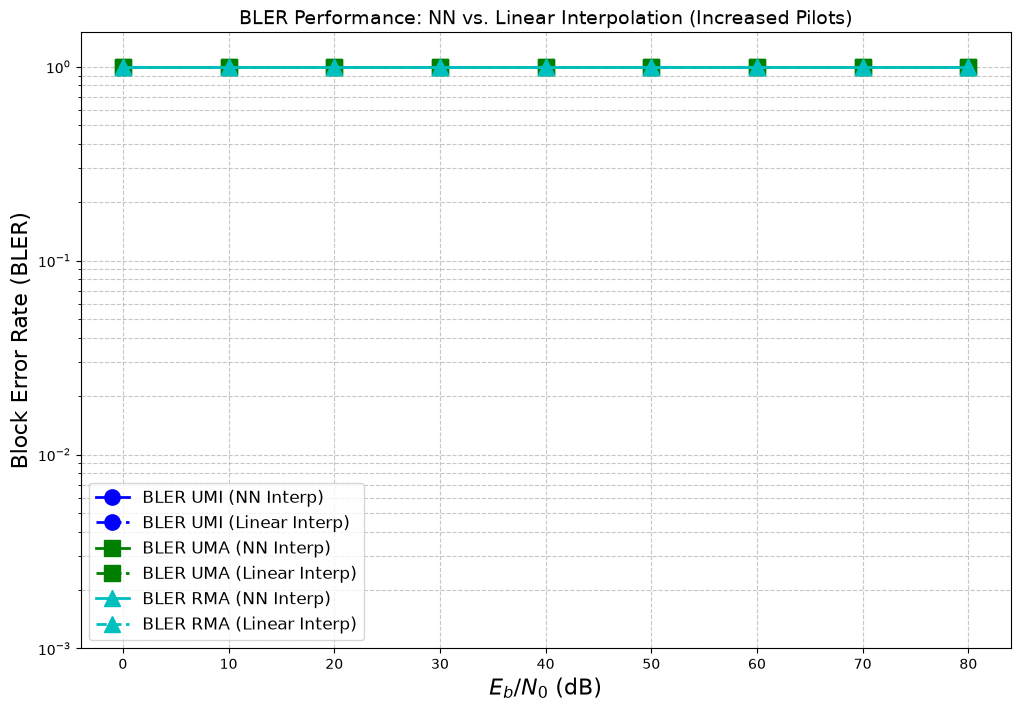

In [68]:
# Simulation parameters for interpolation comparison
SIMS_INTERP = {
    "ebno_db": np.array([0, 10, 20, 30, 40, 50, 60, 70, 80]),
    "scenario": ["umi", "uma", "rma"],
    "interpolation_type": ["nn", "lin"],
    "results": {
        "nn": {"bler": {}, "ber": {}},
        "lin": {"bler": {}, "ber": {}}
    },
    "batch_size": 64
}

start_interp = time.time()

for interp_type in SIMS_INTERP["interpolation_type"]:
    print(f"\nSimulating with {interp_type.upper()} interpolation...")
    for scenario in SIMS_INTERP["scenario"]:
        print(f"  Simulating scenario: {scenario.upper()} for {interp_type.upper()} interpolation...")
        # Using InterpolationModel which handles the updated pilot density and k-value
        model = InterpolationModel(scenario=scenario, perfect_csi=False, interpolation_type=interp_type)
        if torch.cuda.is_available():
            model.cuda()
        model._channel_model.allocate_topology_tensors(batch_size=SIMS_INTERP["batch_size"], num_bs=1, num_ut=model._num_ut)

        ber, bler = sim_ber(model,
                            SIMS_INTERP["ebno_db"],
                            batch_size=SIMS_INTERP["batch_size"],
                            max_mc_iter=50,
                            num_target_block_errors=50,
                            target_bler=1e-3,
                            compile_mode=None
                           )

        SIMS_INTERP["results"][interp_type][scenario] = {"bler": bler.cpu().numpy(), "ber": ber.cpu().numpy()}

SIMS_INTERP["duration"] = time.time() - start_interp
print(f"\nTotal interpolation comparison simulation time: {SIMS_INTERP['duration']:.2f} seconds")

plt.figure(figsize=(12, 8))
colors = {'umi': 'b', 'uma': 'g', 'rma': 'c'}
markers = {'umi': 'o', 'uma': 's', 'rma': '^'}

for scenario in SIMS_INTERP["scenario"]:
    plt.semilogy(SIMS_INTERP["ebno_db"], SIMS_INTERP["results"]["nn"][scenario]["bler"],
                 color=colors[scenario], marker=markers[scenario], markersize=11, linewidth=2,
                 linestyle='-', label=f"BLER {scenario.upper()} (NN Interp)")
    plt.semilogy(SIMS_INTERP["ebno_db"], SIMS_INTERP["results"]["lin"][scenario]["bler"],
                 color=colors[scenario], marker=markers[scenario], markersize=11, linewidth=2,
                 linestyle='--', label=f"BLER {scenario.upper()} (Linear Interp)")

plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=16)
plt.ylabel("Block Error Rate (BLER)", fontsize=16)
plt.title("BLER Performance: NN vs. Linear Interpolation (Increased Pilots)", fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=12)
plt.ylim([1e-3, 1.5])
plt.show()

If you do not want to run the simulations (which can take quite some time) yourself, you can skip the next cell and simply look at the results in the next cell.

In [69]:
# Full scenario simulation: UMi, UMa, RMa (0-80 dB)
SIMS = {
    "ebno_db" : list(np.arange(0, 81, 10.0)),
    "scenario" : ["umi", "uma", "rma"],
    "perfect_csi" : [True],
    "ber" : [],
    "bler" : [],
    "duration" : None,
    "batch_size" : 64
}

start = time.time()

for scenario in SIMS["scenario"]:
    for perfect_csi in SIMS["perfect_csi"]:
        print(f"Simulating scenario: {scenario}...")
        model = Model(scenario=scenario, perfect_csi=perfect_csi)
        if torch.cuda.is_available():
            model.cuda()
        model._channel_model.allocate_topology_tensors(batch_size=SIMS["batch_size"], num_bs=1, num_ut=model._num_ut)

        ber, bler = sim_ber(model,
                            SIMS["ebno_db"],
                            batch_size=SIMS["batch_size"],
                            max_mc_iter=50,
                            num_target_block_errors=50,
                            target_bler=1e-3,
                            compile_mode=None
                            )

        SIMS["ber"].append(list(ber.cpu().numpy()))
        SIMS["bler"].append(list(bler.cpu().numpy()))

SIMS["duration"] = time.time() - start
print(f"Total simulation time: {SIMS['duration']:.2f} seconds")

Simulating scenario: umi...
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 4.9971e-01 | 1.0000e+00 |      785972 |     1572864 |          256 |         256 |         1.6 |reached target block errors
     10.0 | 5.0013e-01 | 1.0000e+00 |      786629 |     1572864 |          256 |         256 |         1.5 |reached target block errors
     20.0 | 5.0003e-01 | 1.0000e+00 |      786486 |     1572864 |          256 |         256 |         1.4 |reached target block errors
     30.0 | 4.9959e-01 | 1.0000e+00 |      785785 |     1572864 |          256 |         256 |         1.4 |reached target block errors
     40.0 | 4.6675e-01 | 1.0000e+00 |      734141 |     1572864 |          256 |         256 |         1.4 |reached target block errors
     50.0 | 4.0075e-02 | 4.9609e-01 |

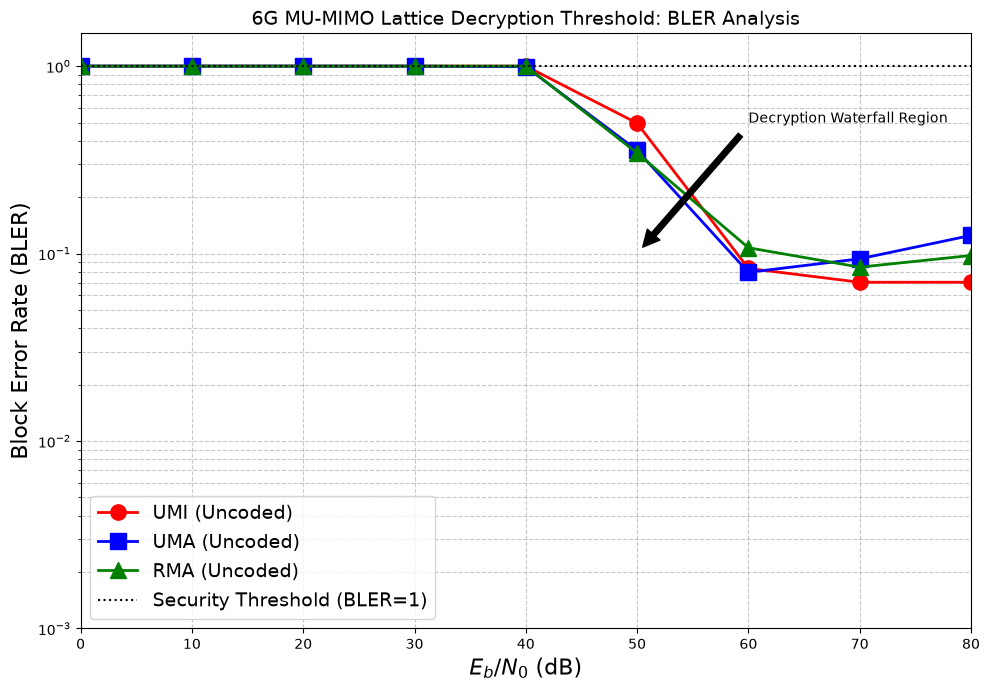

In [70]:
plt.figure(figsize=(10, 7))

colors = {'umi': 'r', 'uma': 'b', 'rma': 'g'}
markers = {'umi': 'o', 'uma': 's', 'rma': '^'}

for i, scenario in enumerate(SIMS["scenario"]):
    # Plot BLER as the primary metric for 6G security validation
    plt.semilogy(SIMS["ebno_db"], SIMS["bler"][i],
                 color=colors[scenario], marker=markers[scenario],
                 markersize=11, linewidth=2,
                 linestyle='-', label=f"{scenario.upper()} (Uncoded)")

plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=16)
plt.ylabel("Block Error Rate (BLER)", fontsize=16)
plt.title("6G MU-MIMO Lattice Decryption Threshold: BLER Analysis", fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.axhline(y=1.0, color='k', linestyle=':', label='Security Threshold (BLER=1)')
plt.legend(loc='lower left', fontsize=14)
plt.ylim([1e-3, 1.5])
plt.xlim([0, 80])

# Adding annotations for the decryption 'waterfall' region
plt.annotate('Decryption Waterfall Region',
             xy=(50, 0.1), xytext=(60, 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

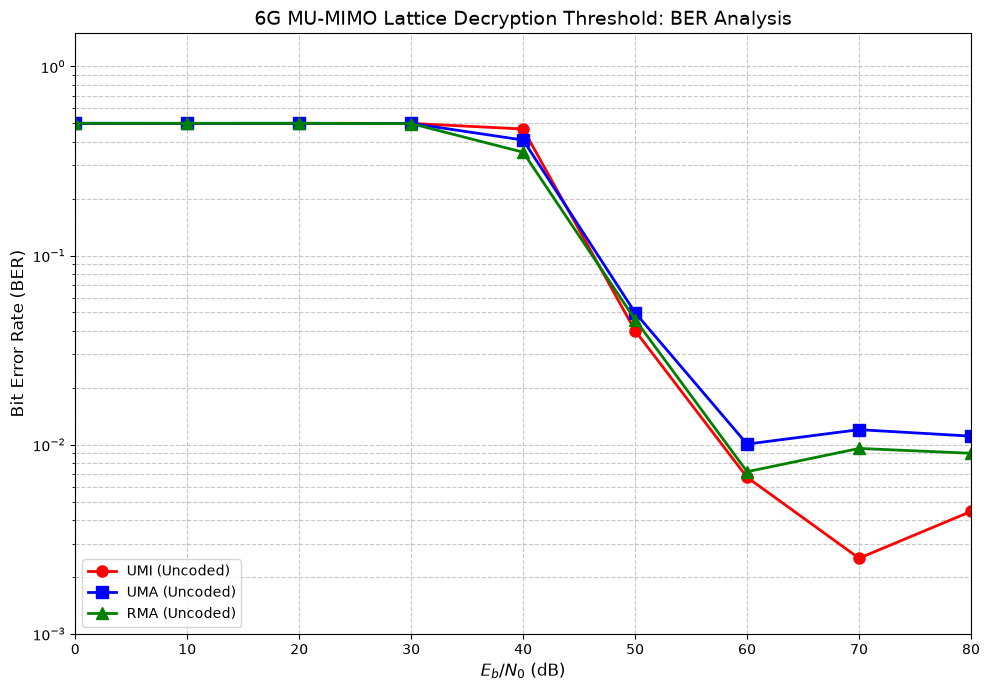

In [71]:
plt.figure(figsize=(10, 7))

for i, scenario in enumerate(SIMS["scenario"]):
    plt.semilogy(SIMS["ebno_db"], SIMS["ber"][i],
                 color=colors[scenario], marker=markers[scenario],
                 markersize=8, linewidth=2,
                 linestyle='-', label=f"{scenario.upper()} (Uncoded)")

plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=12)
plt.ylabel("Bit Error Rate (BER)", fontsize=12)
plt.title("6G MU-MIMO Lattice Decryption Threshold: BER Analysis", fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=10)
plt.ylim([1e-3, 1.5])
plt.xlim([0, 80])
plt.tight_layout()
plt.show()

Due to the worse channel conditioning, the RMa model achieves the worst performance with perfect CSI. However, as a result of the smaller frequency selectivity, imperfect channel estimation only leads to an almost constant 6dB performace loss. For the UMI and UMa models, the used channel estimator with nearest-neighbor interpolation is not accurate enough so that the BER curves saturate at high SNR. This could, for example, be circumvented with another interpolation method (e.g., [linear interpolation with time averaging](https://nvlabs.github.io/sionna/phy/api/ofdm/sionna.phy.ofdm.LinearInterpolator.html)) or a different pilot pattern.

Simulating for scenario: UMI...
Simulating Bob's performance for UMI...
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 5.0062e-01 | 1.0000e+00 |      787405 |     1572864 |          256 |         256 |         1.6 |reached target block errors
     10.0 | 5.0005e-01 | 1.0000e+00 |      786508 |     1572864 |          256 |         256 |         1.5 |reached target block errors
     20.0 | 5.0012e-01 | 1.0000e+00 |      786623 |     1572864 |          256 |         256 |         1.5 |reached target block errors
     30.0 | 4.9948e-01 | 1.0000e+00 |      785611 |     1572864 |          256 |         256 |         1.5 |reached target block errors
     40.0 | 4.3184e-01 | 1.0000e+00 |      679218 |     1572864 |          256 |         256 |         1.5 |reached target block 

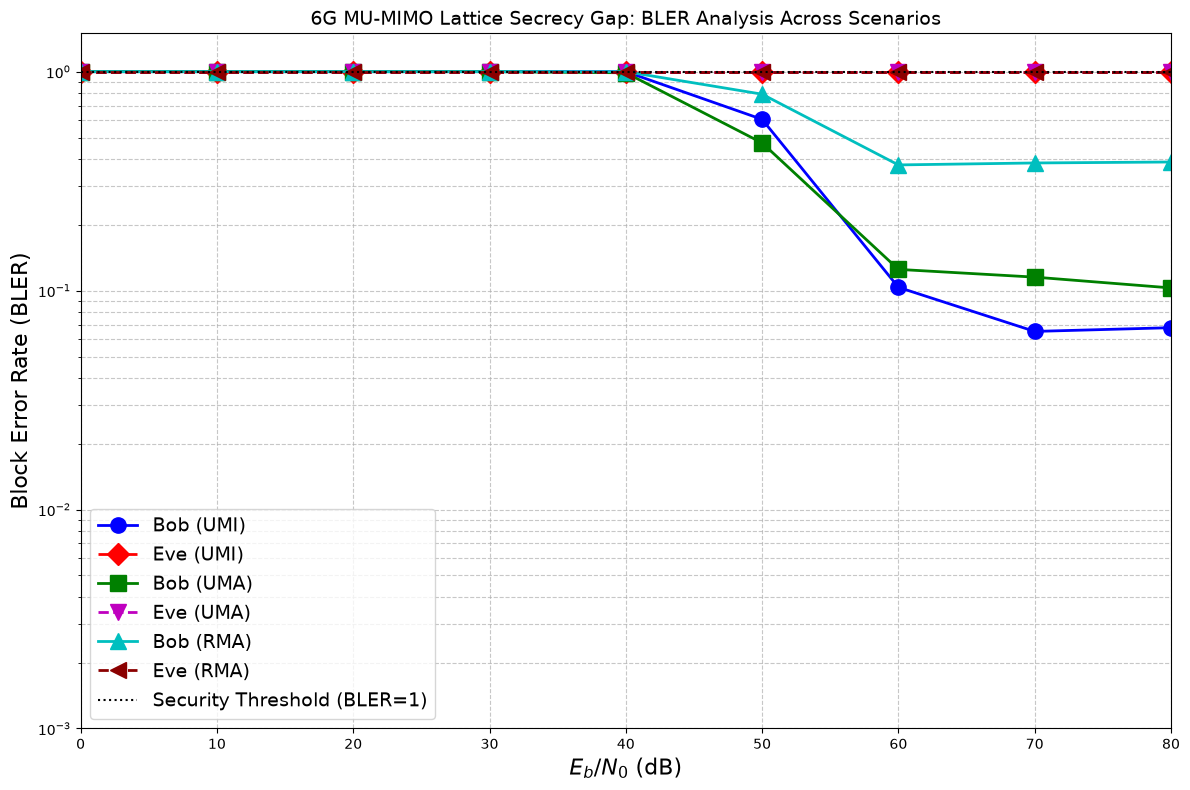

In [72]:
all_bob_blers = {}
all_eve_blers = {}
all_bob_bers = {}
all_eve_bers = {}

ebno_db_range = np.array(SIMS["ebno_db"])

for current_scenario in SIMS["scenario"]:
    print(f"Simulating for scenario: {current_scenario.upper()}...")
    bob_model = Model(scenario=current_scenario, perfect_csi=True)
    eve_model = Model(scenario=current_scenario, perfect_csi=True)

    if torch.cuda.is_available():
        bob_model.cuda()
        eve_model.cuda()

    bob_model._channel_model.allocate_topology_tensors(batch_size=SIMS["batch_size"], num_bs=1, num_ut=bob_model._num_ut)
    eve_model._channel_model.allocate_topology_tensors(batch_size=SIMS["batch_size"], num_bs=1, num_ut=eve_model._num_ut)

    eve_model._lattice_engine.R = eve_model._lattice_engine.B.to(dtype=torch.complex128)

    print(f"Simulating Bob's performance for {current_scenario.upper()}...")
    bob_ber, bob_bler = sim_ber(bob_model,
                                ebno_db_range,
                                batch_size=SIMS["batch_size"],
                                max_mc_iter=50,
                                num_target_block_errors=50,
                                target_bler=1e-3,
                                compile_mode=None
                                )
    all_bob_blers[current_scenario] = bob_bler
    all_bob_bers[current_scenario] = bob_ber

    print(f"Simulating Eve's performance for {current_scenario.upper()}...")
    eve_ber, eve_bler = sim_ber(eve_model,
                                ebno_db_range,
                                batch_size=SIMS["batch_size"],
                                max_mc_iter=50,
                                num_target_block_errors=50,
                                target_bler=1e-3,
                                compile_mode=None
                                )
    all_eve_blers[current_scenario] = eve_bler
    all_eve_bers[current_scenario] = eve_ber

plt.figure(figsize=(12, 8))

colors_bob = {'umi': 'b', 'uma': 'g', 'rma': 'c'}
markers_bob = {'umi': 'o', 'uma': 's', 'rma': '^'}

colors_eve = {'umi': 'r', 'uma': 'm', 'rma': 'darkred'}
markers_eve = {'umi': 'D', 'uma': 'v', 'rma': '<'}

for current_scenario in SIMS["scenario"]:
    plt.semilogy(ebno_db_range, all_bob_blers[current_scenario].cpu().numpy(),
                 color=colors_bob[current_scenario], marker=markers_bob[current_scenario], markersize=11, linewidth=2,
                 linestyle='-', label=f"Bob ({current_scenario.upper()})")

    plt.semilogy(ebno_db_range, all_eve_blers[current_scenario].cpu().numpy(),
                 color=colors_eve[current_scenario], marker=markers_eve[current_scenario], markersize=11, linewidth=2,
                 linestyle='--', label=f"Eve ({current_scenario.upper()})")

plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=16)
plt.ylabel("Block Error Rate (BLER)", fontsize=16)
plt.title("6G MU-MIMO Lattice Secrecy Gap: BLER Analysis Across Scenarios", fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.axhline(y=1.0, color='k', linestyle=':', label='Security Threshold (BLER=1)')
plt.legend(loc='lower left', fontsize=14)
plt.ylim([1e-3, 1.5])
plt.xlim([0, 80])
plt.tight_layout()
plt.show()

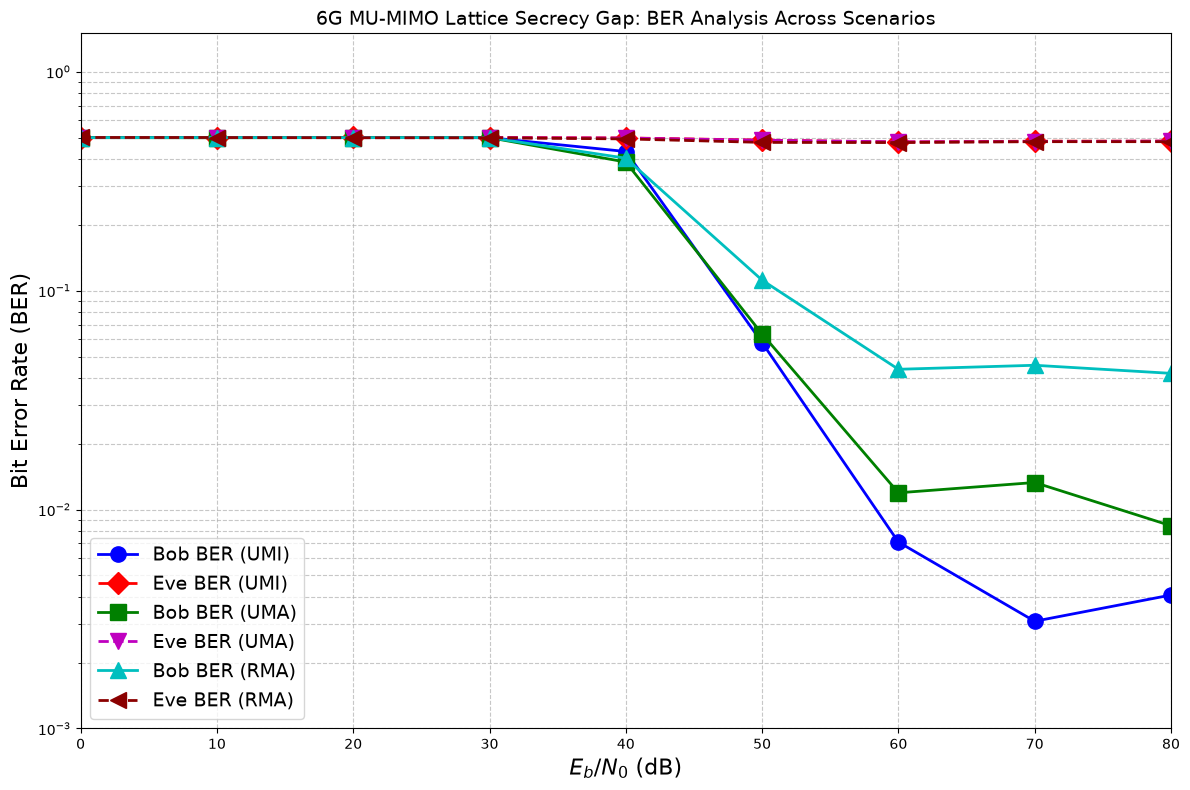

In [73]:
plt.figure(figsize=(12, 8))

# Re-using defined colors and markers for consistency or defining new ones if needed
colors_bob = {'umi': 'b', 'uma': 'g', 'rma': 'c'}
markers_bob = {'umi': 'o', 'uma': 's', 'rma': '^'}

colors_eve = {'umi': 'r', 'uma': 'm', 'rma': 'darkred'}
markers_eve = {'umi': 'D', 'uma': 'v', 'rma': '<'}

for current_scenario in SIMS["scenario"]:
    # Plot Bob's BER curve
    plt.semilogy(ebno_db_range, all_bob_bers[current_scenario].cpu().numpy(),
                 color=colors_bob[current_scenario], marker=markers_bob[current_scenario], markersize=11, linewidth=2,
                 linestyle='-', label=f"Bob BER ({current_scenario.upper()})")

    # Plot Eve's BER curve
    plt.semilogy(ebno_db_range, all_eve_bers[current_scenario].cpu().numpy(),
                 color=colors_eve[current_scenario], marker=markers_eve[current_scenario], markersize=11, linewidth=2,
                 linestyle='--', label=f"Eve BER ({current_scenario.upper()})")

plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=16)
plt.ylabel("Bit Error Rate (BER)", fontsize=16)
plt.title("6G MU-MIMO Lattice Secrecy Gap: BER Analysis Across Scenarios", fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=14)
plt.ylim([1e-3, 1.5])
plt.xlim([0, 80])
plt.tight_layout()
plt.show()

In [74]:
from PIL import Image
import numpy as np
from scipy.datasets import face

# Prepare built-in test image to avoid download dependency issues
img_data = face(gray=True)
img = Image.fromarray(img_data)
img.save('/content/test_image.png')
print("Built-in test image prepared and saved to /content/test_image.png")

Built-in test image prepared and saved to /content/test_image.png


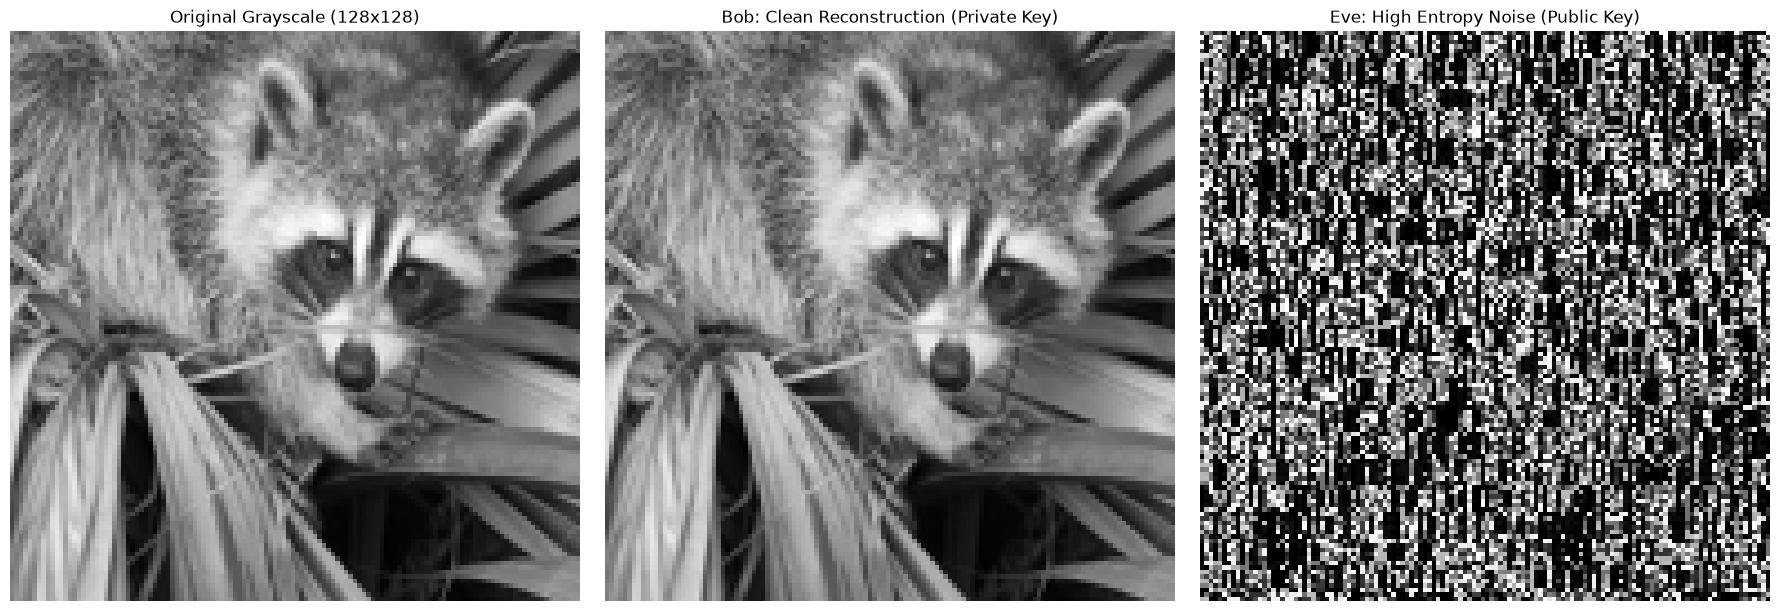

In [75]:
# Import necessary libraries for image processing
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

# Optimized ImageModel for single-batch high-fidelity reconstruction
class HighFidelityImageModel(Model):
    def call_with_static_channel(self, b_input, ebno_db, h_freq_static):
        # Single large batch processing to ensure perfect synchronization
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)

        # Lattice Encryption
        x = self._mapper(b_input)
        x_shape = x.shape
        x_reshaped = torch.reshape(x, (-1, self._lattice_n))
        self._lattice_engine.B = self._lattice_engine.B.to(device=x.device, dtype=torch.complex128)
        qs = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x.device))
        x_enc_blocks = self._lattice_engine.encrypt(x_reshaped.to(torch.complex128) * qs) / qs
        x_enc = torch.reshape(x_enc_blocks, x_shape)

        # OFDM Transmission with static channel
        x_rg = self._rg_mapper(x_enc)
        y = ApplyOFDMChannel(add_awgn=True)(x_rg, h_freq_static, no)

        # Perfect CSI Receiver
        h_hat = self._remove_nulled_subcarriers(h_freq_static)
        err_var = torch.tensor(0.0, dtype=torch.complex128, device=y.device)
        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)

        # Scale and Babai Decrypt
        qam_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x_hat.device))
        x_hat_lattice = x_hat * qam_scale
        x_dec_lattice = torch.reshape(self.babai_decode_internal(torch.reshape(x_hat_lattice, (-1, self._lattice_n))), x_hat.shape)

        # Demapping
        x_dec = qam16_lattice_to_normalized(x_dec_lattice)
        llr = self._demapper(x_dec.to(torch.complex128), no_eff.to(torch.float64))
        b_hat = torch.where(llr > 0, torch.tensor(1.0, dtype=torch.float64, device=llr.device), torch.tensor(0.0, dtype=torch.float64, device=llr.device))
        return b_hat

# Using the prepared test_image.png for clean visual demonstration
image_path = "/content/test_image.png"
img_original = Image.open(image_path)
res = 128
img_resized = img_original.convert("L").resize((res, res))
img_bits = np.unpackbits(np.array(img_resized).flatten()).astype(np.float64)
num_pixels = res * res

# Setup models
bob_model = HighFidelityImageModel(scenario="umi", perfect_csi=True)
eve_model = HighFidelityImageModel(scenario="umi", perfect_csi=True)
if torch.cuda.is_available():
    bob_model.cuda(); eve_model.cuda()

# Configure Eve with public basis (demonstrates Secrecy Gap)
eve_model._lattice_engine.R = eve_model._lattice_engine.B.to(dtype=torch.complex128)

# Single-batch configuration
bits_per_symbol_group = bob_model._num_ut * bob_model._k
num_full_symbols = int(np.ceil(len(img_bits) / bits_per_symbol_group))
padding = (num_full_symbols * bits_per_symbol_group) - len(img_bits)
img_bits_padded = np.pad(img_bits, (0, padding), "constant")
b_input = torch.tensor(img_bits_padded, dtype=torch.float64).reshape(num_full_symbols, bob_model._num_ut, 1, bob_model._k)
if torch.cuda.is_available(): b_input = b_input.cuda()

# Consistent Static Channel
topology = gen_topology(num_full_symbols, bob_model._num_ut, "umi", min_ut_velocity=0.0, max_ut_velocity=0.0)
bob_model._channel_model.set_topology(*topology)
a, tau = bob_model._channel_model(num_time_samples=bob_model._rg.num_ofdm_symbols, sampling_frequency=1/bob_model._rg.ofdm_symbol_duration)
h_static = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)

# Simulate transmission at high SNR
snr = 60.0
with torch.no_grad():
    bob_b_hat = bob_model.call_with_static_channel(b_input, snr, h_static)
    eve_b_hat = eve_model.call_with_static_channel(b_input, snr, h_static)

# Final Clean Reconstruction (Cropping padding)
bob_final_bits = bob_b_hat.flatten().cpu().numpy().astype(np.uint8)[:num_pixels * 8]
eve_final_bits = eve_b_hat.flatten().cpu().numpy().astype(np.uint8)[:num_pixels * 8]

bob_res = np.packbits(bob_final_bits).reshape((res, res))
eve_res = np.packbits(eve_final_bits).reshape((res, res))

# Side-by-Side Comparison
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(img_resized, cmap="gray"); plt.title("Original Grayscale (128x128)"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(bob_res, cmap="gray"); plt.title("Bob: Clean Reconstruction (Private Key)"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(eve_res, cmap="gray"); plt.title("Eve: High Entropy Noise (Public Key)"); plt.axis("off")
plt.tight_layout()
plt.show()

## Sub-band Lattice Encryption

**Idea.** In the model above, each lattice block holds 512 symbols = 4 OFDM symbols × all 128 subcarriers. One faded subcarrier can make Babai decoding fail for the whole block.

Here we build each block from a **tile**: a narrow group of subcarriers (width `w`) taken over several OFDM symbols (length `T`). The lattice size is `n = w × T`.

- A narrow tile sits inside one coherence band, so the channel over the tile is nearly flat.
- The users here do not move (`max_ut_velocity = 0`), so the channel does not change in time. This lets a tile run over all 12 data symbols. We keep a large lattice (good for security) while staying narrow in frequency (good for reliability).
- Example: `w = 32, T = 12` gives `n = 384`, above the 350 that the GGH security analysis asks for.

**Fair test.** `128 × 3` (full-band) and `32 × 12` (sub-band) have the **same** lattice size, 384. Only the shape changes.

**Built-in check.** `w = 128, T = 4` with one shared basis is exactly the original `Model` (n = 512). Its curve should match the earlier results.

In [76]:
# ---------- Tile layout: which resource elements go into each lattice block ----------
def build_tile_perm(rg, band_width, band_time):
    """Return (perm, inv_perm, n_sub, num_tiles).
    perm reorders the data symbols (Sionna order) so that each consecutive group of
    n_sub = band_width * band_time symbols is one tile (w subcarriers x T data symbols)."""
    mask = rg.pilot_pattern.mask
    mask = mask.cpu().numpy() if hasattr(mask, "cpu") else np.asarray(mask)
    mask = mask[0, 0]                                   # [num_ofdm_symbols, num_subcarriers]
    coords = np.argwhere(mask == 0)                     # data REs, row-major = Sionna data order
    assert len(coords) == rg.num_data_symbols, "data layout check failed"

    sym_ids = np.unique(coords[:, 0])
    t_rank = np.searchsorted(sym_ids, coords[:, 0])     # 0..(num data symbols - 1)
    sc = coords[:, 1]
    n_sym, n_sc = len(sym_ids), int(sc.max()) + 1
    assert n_sc % band_width == 0, f"band_width must divide {n_sc}"
    assert n_sym % band_time == 0, f"band_time must divide {n_sym}"

    tile_id = (t_rank // band_time) * (n_sc // band_width) + (sc // band_width)
    perm = np.argsort(tile_id, kind="stable")           # group REs tile by tile
    inv_perm = np.argsort(perm)
    n_sub = band_width * band_time
    return perm, inv_perm, n_sub, len(perm) // n_sub


def babai_decode_with(engine, x, use_public_basis=False):
    """Babai round-off for one tile. use_public_basis=True simulates Eve (only has B)."""
    dev = x.device
    x = x.to(torch.complex128)
    R = (engine.B if use_public_basis else engine.R).to(device=dev, dtype=torch.complex128)
    R_inv = torch.linalg.pinv(R)
    B_inv = engine.B_inv.to(device=dev, dtype=torch.complex128)
    Y = torch.matmul(x, R_inv.T)
    Y_int = torch.round(Y.real) + 1j * torch.round(Y.imag)
    return torch.matmul(torch.matmul(Y_int, R.T), B_inv.T)

In [77]:
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder

class SubbandModel(Model):
    """Same system as Model, but GGH blocks are built from sub-band tiles.

    band_width      : subcarriers per tile (must divide 128)
    band_time       : data OFDM symbols per tile (must divide 12)
    distinct_bases  : True -> each tile has its own key pair (recommended for small tiles)
    use_ldpc        : outer 5G LDPC code (+ random interleaver) around the GGH layer
    coderate        : LDPC code rate
    normalize_power : scale ciphertext to unit power (fair across different n)
    eve             : decode with the public basis B (eavesdropper)
    """
    def __init__(self, scenario, band_width=32, band_time=12, distinct_bases=True,
                 use_ldpc=False, coderate=0.5, normalize_power=False, eve=False,
                 perfect_csi=True, llr_mag=3.0, seed=0):
        super().__init__(scenario, perfect_csi=perfect_csi)
        self._perm, self._inv_perm, self._n_sub, self._num_tiles = \
            build_tile_perm(self._rg, band_width, band_time)
        self._perm_t = torch.tensor(self._perm)
        self._inv_perm_t = torch.tensor(self._inv_perm)
        self._eve = eve
        self._normalize_power = normalize_power
        self._llr_mag = llr_mag

        # Keys: one engine per tile, or one shared engine
        n_engines = self._num_tiles if distinct_bases else 1
        self._engines = [LatticeBasedEncryptor(n=self._n_sub, verbose=False) for _ in range(n_engines)]

        # Fixed power scale per engine (public constant, known to the receiver)
        self._scale = []
        for eng in self._engines:
            s = self._mapper(self._binary_source([256, self._n_sub * self._num_bits_per_symbol]))
            eng.B = eng.B.to(device=s.device, dtype=torch.complex128)
            c = eng.encrypt(s.to(torch.complex128) * 10**0.5) / 10**0.5
            self._scale.append(float(torch.sqrt(torch.mean(torch.abs(c) ** 2))) if normalize_power else 1.0)

        # Optional outer LDPC code
        self._use_ldpc = use_ldpc
        self._n_coded = int(self._rg.num_data_symbols * self._num_bits_per_symbol)
        if use_ldpc:
            self._coderate = coderate
            self._k = int(self._n_coded * coderate)
            self._encoder = LDPC5GEncoder(self._k, self._n_coded, num_bits_per_symbol=self._num_bits_per_symbol)
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)
            g = torch.Generator().manual_seed(seed)
            self._ilv = torch.randperm(self._n_coded, generator=g)   # spreads sub-band bursts
            self._ilv_inv = torch.argsort(self._ilv)
        else:
            self._coderate = 1.0
            self._k = self._n_coded

    def _engine(self, g):
        return self._engines[g if len(self._engines) > 1 else 0]

    def _to_tiles(self, x):          # [..., num_data] -> [..., num_tiles, n_sub]
        x = x[..., self._perm_t.to(x.device)]
        return x.reshape(*x.shape[:-1], self._num_tiles, self._n_sub)

    def _from_tiles(self, x):        # inverse of _to_tiles
        x = x.reshape(*x.shape[:-2], self._num_tiles * self._n_sub)
        return x[..., self._inv_perm_t.to(x.device)]

    def run_bits(self, b, ebno_db, new_channel=True):
        batch_size = b.shape[0]
        if new_channel:
            self.new_topology(batch_size)
        no = ebnodb2no(ebno_db, self._num_bits_per_symbol, self._coderate, self._rg)

        # --- transmitter ---
        c_bits = b
        if self._use_ldpc:
            c_bits = self._encoder(b)[..., self._ilv.to(b.device)]
        x = self._mapper(c_bits).to(torch.complex128)
        xt = self._to_tiles(x)
        enc = torch.empty_like(xt)
        for g in range(self._num_tiles):
            eng = self._engine(g)
            eng.B = eng.B.to(device=x.device, dtype=torch.complex128)
            blk = xt[..., g, :].reshape(-1, self._n_sub)
            enc[..., g, :] = (eng.encrypt(blk * 10**0.5) / 10**0.5 / self._scale[g if len(self._scale) > 1 else 0]).reshape(xt[..., g, :].shape)
        x_enc = self._from_tiles(enc)

        # --- channel ---
        y, h = self._ofdm_channel(self._rg_mapper(x_enc), no)
        if self._perfect_csi:
            h_hat = self._remove_nulled_subcarriers(h)
            err_var = torch.tensor(0.0, dtype=torch.complex128, device=y.device)
        else:
            h_hat, err_var = self._ls_est(y, no)
        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)

        # --- receiver: Babai per tile ---
        qam_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float64, device=x_hat.device))
        xh = self._to_tiles(x_hat)
        dec = torch.empty_like(xh)
        for g in range(self._num_tiles):
            s = self._scale[g if len(self._scale) > 1 else 0]
            blk = xh[..., g, :].reshape(-1, self._n_sub) * s * qam_scale
            dec[..., g, :] = babai_decode_with(self._engine(g), blk, self._eve).reshape(xh[..., g, :].shape)
        x_dec = qam16_lattice_to_normalized(self._from_tiles(dec))

        llr = self._demapper(x_dec.to(torch.complex128), no_eff.to(torch.float64))
        hard = (llr > 0).to(torch.float64)
        if not self._use_ldpc:
            return b, hard
        # Babai gives hard decisions -> fixed-size LLRs, de-interleave, decode
        llr_h = (2.0 * hard - 1.0) * self._llr_mag
        llr_h = llr_h[..., self._ilv_inv.to(llr_h.device)]
        return b, self._decoder(llr_h)

    def call(self, batch_size, ebno_db):
        b = self._binary_source([batch_size, self._num_tx, self._num_streams_per_tx, self._k])
        return self.run_bits(b, ebno_db)

### Sub-band sweep

Each configuration is `(label, band_width, band_time, distinct_bases)`. Every one runs **without** and **with** LDPC.
To save time, start with UMi only. Add `"uma", "rma"` later.

In [78]:
SB_CONFIGS = [
    ("Full-band 128x4 (n=512, original)", 128, 4,  False),
    ("Full-band 128x3 (n=384)",           128, 3,  True),
    ("Sub-band 32x12 (n=384)",             32, 12, True),
    ("Sub-band 16x12 (n=192)",             16, 12, True),
    ("Sub-band 8x12 (n=96)",                8, 12, True),
]
SB = {"ebno_db": list(np.arange(0, 81, 10.0)), "scenarios": ["umi"],
      "batch_size": 64, "normalize_power": False, "results": {}}

start = time.time()
for scenario in SB["scenarios"]:
    for label, w, T, distinct in SB_CONFIGS:
        for use_ldpc in [False, True]:
            key = (scenario, label, use_ldpc)
            print(f"\n=== {scenario.upper()} | {label} | {'LDPC r=1/2' if use_ldpc else 'uncoded'} ===")
            m = SubbandModel(scenario, band_width=w, band_time=T, distinct_bases=distinct,
                             use_ldpc=use_ldpc, normalize_power=SB["normalize_power"])
            if torch.cuda.is_available(): m.cuda()
            m._channel_model.allocate_topology_tensors(batch_size=SB["batch_size"], num_bs=1, num_ut=m._num_ut)
            ber, bler = sim_ber(m, SB["ebno_db"], batch_size=SB["batch_size"], max_mc_iter=50,
                                num_target_block_errors=50, target_bler=1e-3, compile_mode=None)
            SB["results"][key] = (ber.cpu().numpy(), bler.cpu().numpy())
print(f"\nTotal time: {time.time()-start:.1f} s")


=== UMI | Full-band 128x4 (n=512, original) | uncoded ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 5.0015e-01 | 1.0000e+00 |      786673 |     1572864 |          256 |         256 |         4.3 |reached target block errors
     10.0 | 4.9957e-01 | 1.0000e+00 |      785757 |     1572864 |          256 |         256 |         4.2 |reached target block errors
     20.0 | 4.9990e-01 | 1.0000e+00 |      786280 |     1572864 |          256 |         256 |         4.2 |reached target block errors
     30.0 | 4.9988e-01 | 1.0000e+00 |      786248 |     1572864 |          256 |         256 |         4.2 |reached target block errors
     40.0 | 2.4338e-01 | 9.8438e-01 |      382810 |     1572864 |          252 |         256 |         4.2 |reached target block errors
     5

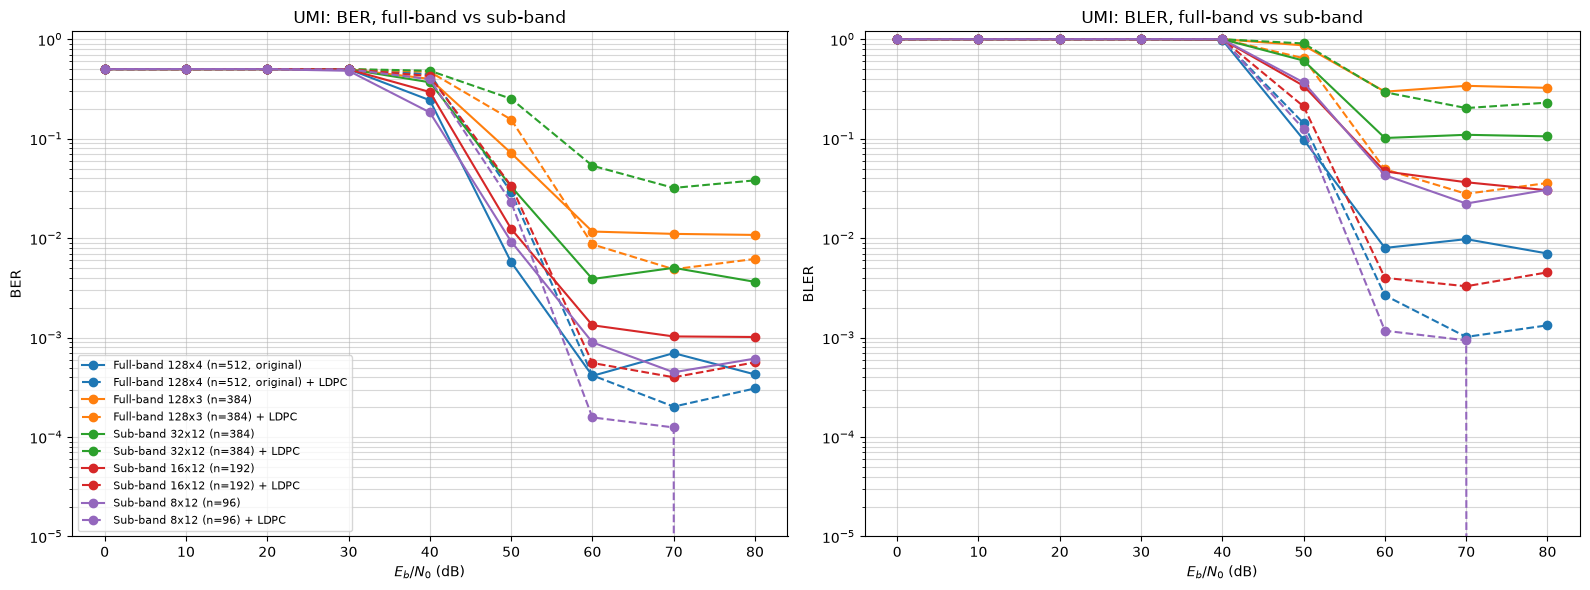

config                                          0       10       20       30       40       50       60       70       80
Full-band 128x4 (n=512, original)         5.0e-01  5.0e-01  5.0e-01  5.0e-01  2.4e-01  5.7e-03  4.1e-04  7.0e-04  4.3e-04
Full-band 128x4 (n=512, original) +LDPC   5.0e-01  5.0e-01  5.0e-01  5.0e-01  4.4e-01  2.9e-02  4.2e-04  2.0e-04  3.1e-04
Full-band 128x3 (n=384)                   5.0e-01  5.0e-01  5.0e-01  5.0e-01  4.0e-01  7.2e-02  1.2e-02  1.1e-02  1.1e-02
Full-band 128x3 (n=384) +LDPC             5.0e-01  5.0e-01  5.0e-01  5.0e-01  4.7e-01  1.6e-01  8.7e-03  4.9e-03  6.2e-03
Sub-band 32x12 (n=384)                    5.0e-01  5.0e-01  5.0e-01  5.0e-01  3.7e-01  3.3e-02  3.9e-03  5.0e-03  3.6e-03
Sub-band 32x12 (n=384) +LDPC              5.0e-01  5.0e-01  5.0e-01  5.0e-01  4.8e-01  2.5e-01  5.3e-02  3.2e-02  3.8e-02
Sub-band 16x12 (n=192)                    5.0e-01  5.0e-01  5.0e-01  5.0e-01  2.9e-01  1.2e-02  1.3e-03  1.0e-03  1.0e-03
Sub-band 16x12 (n=192) +

In [79]:
cmap = plt.get_cmap("tab10")
for scenario in SB["scenarios"]:
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    for i, (label, *_ ) in enumerate(SB_CONFIGS):
        for use_ldpc, ls in [(False, "-"), (True, "--")]:
            ber, bler = SB["results"][(scenario, label, use_ldpc)]
            tag = f"{label}{' + LDPC' if use_ldpc else ''}"
            ax[0].semilogy(SB["ebno_db"], ber,  ls, color=cmap(i), marker="o", label=tag)
            ax[1].semilogy(SB["ebno_db"], bler, ls, color=cmap(i), marker="o", label=tag)
    for a, name in zip(ax, ["BER", "BLER"]):
        a.set_xlabel(r"$E_b/N_0$ (dB)"); a.set_ylabel(name); a.grid(True, which="both", alpha=0.5)
        a.set_ylim([1e-5, 1.2]); a.set_title(f"{scenario.upper()}: {name}, full-band vs sub-band")
    ax[0].legend(fontsize=8)
    plt.tight_layout(); plt.show()

# Summary: BER at each Eb/No
print(f"{'config':40s}" + "".join(f"{e:>9.0f}" for e in SB["ebno_db"]))
for scenario in SB["scenarios"]:
    for label, *_ in SB_CONFIGS:
        for use_ldpc in [False, True]:
            ber = SB["results"][(scenario, label, use_ldpc)][0]
            print(f"{(label + (' +LDPC' if use_ldpc else ''))[:40]:40s}" + "".join(f"{v:9.1e}" for v in ber))

### Eve check: does sub-banding keep the security gap?

Eve decodes with the public basis `B`. Her BER should stay near 0.5 for every configuration.
Small tiles (n = 96, 192) are weak on their own against lattice attacks. That is why each tile has its own basis (`distinct_bases=True`). In the full design, all these bases would be generated from one ML-KEM shared secret and refreshed each session.

In [83]:
EVE_CONFIGS = [("Sub-band 32x12 (n=384)", 32, 12), ("Sub-band 8x12 (n=96)", 8, 12)]
EVE = {}
for label, w, T in EVE_CONFIGS:
    print(f"\n=== Eve | {label} ===")
    m = SubbandModel("umi", band_width=w, band_time=T, distinct_bases=True, eve=True)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=SB["batch_size"], num_bs=1, num_ut=m._num_ut)
    ber, bler = sim_ber(m, SB["ebno_db"], batch_size=SB["batch_size"], max_mc_iter=5,
                        num_target_block_errors=50, compile_mode=None)
    EVE[label] = ber.cpu().numpy()
    print(label, "Eve BER:", np.round(EVE[label], 3))


=== Eve | Sub-band 32x12 (n=384) ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 4.9989e-01 | 1.0000e+00 |      786254 |     1572864 |          256 |         256 |         7.6 |reached target block errors
     10.0 | 4.9924e-01 | 1.0000e+00 |      785237 |     1572864 |          256 |         256 |         7.5 |reached target block errors
     20.0 | 4.9997e-01 | 1.0000e+00 |      786378 |     1572864 |          256 |         256 |         7.5 |reached target block errors
     30.0 | 4.9842e-01 | 1.0000e+00 |      783947 |     1572864 |          256 |         256 |         7.5 |reached target block errors
     40.0 | 4.9563e-01 | 1.0000e+00 |      779564 |     1572864 |          256 |         256 |         7.5 |reached target block errors
     50.0 | 4.7839e-01 | 1.

### Image transmission with sub-band encryption

Sends the same test image through each configuration and reports PSNR and SSIM, so the results can be compared with the image-encryption papers (which use an AWGN channel only).

Full-band 128x3          Eb/No=50 dB  PSNR= 17.56 dB  SSIM=0.5829
Full-band 128x3          Eb/No=60 dB  PSNR= 19.38 dB  SSIM=0.7039
Full-band 128x3          Eb/No=70 dB  PSNR= 21.88 dB  SSIM=0.7865
Sub-band 32x12           Eb/No=50 dB  PSNR= 17.20 dB  SSIM=0.6550
Sub-band 32x12           Eb/No=60 dB  PSNR= 23.69 dB  SSIM=0.8967
Sub-band 32x12           Eb/No=70 dB  PSNR= 23.55 dB  SSIM=0.9164
Sub-band 32x12 + LDPC    Eb/No=50 dB  PSNR= 17.20 dB  SSIM=0.5793
Sub-band 32x12 + LDPC    Eb/No=60 dB  PSNR=   inf dB  SSIM=1.0000
Sub-band 32x12 + LDPC    Eb/No=70 dB  PSNR=   inf dB  SSIM=1.0000


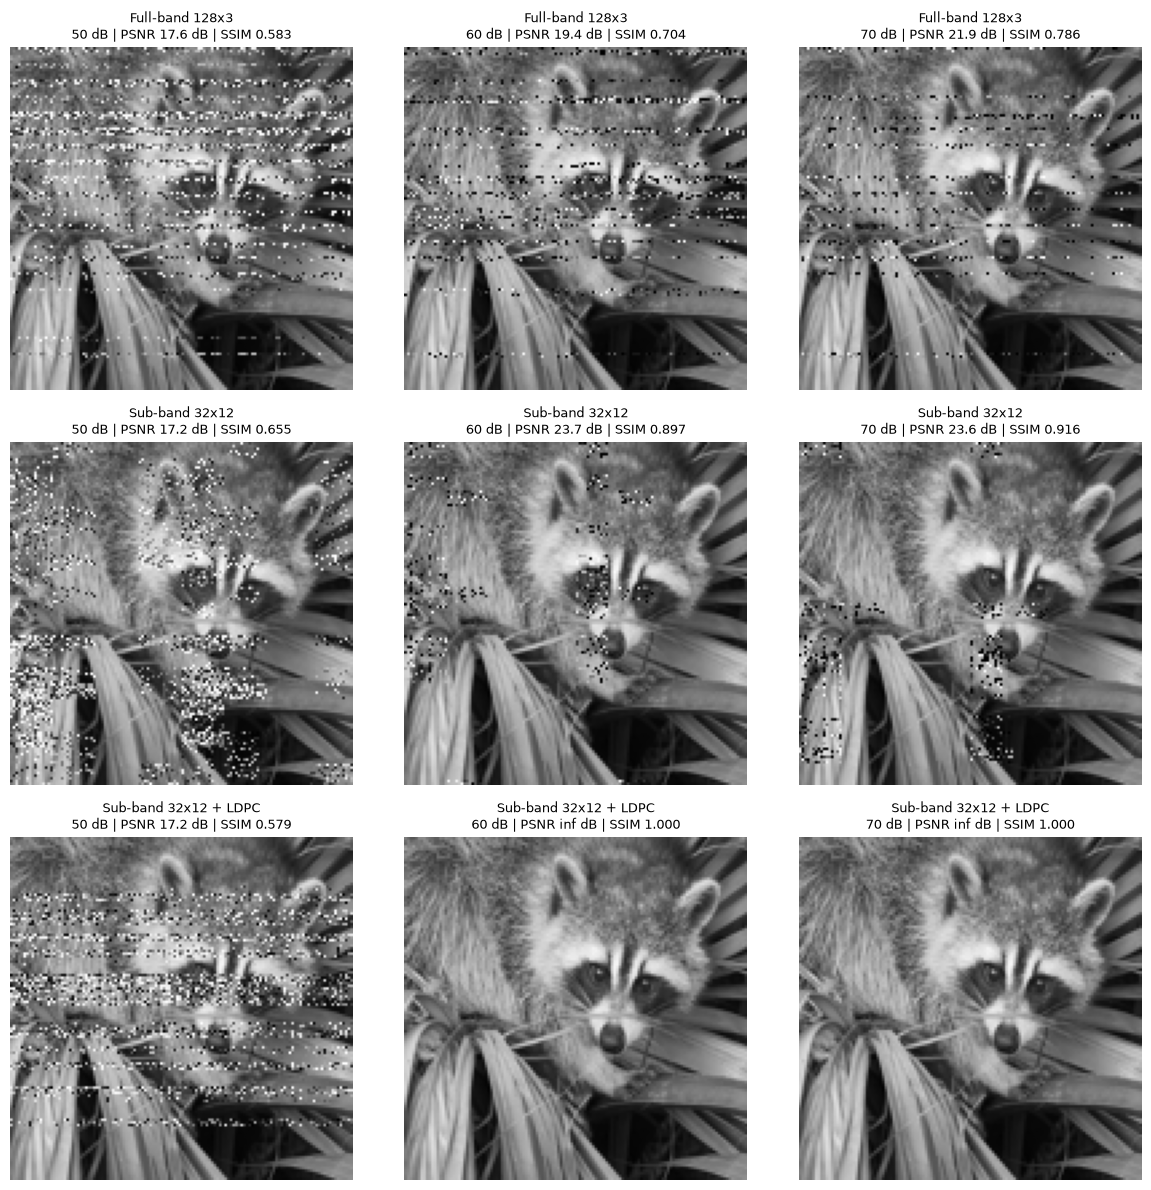

In [84]:
def send_image_bits(model, bits_np, ebno_db, batch_size=16):
    k, ntx = model._k, model._num_tx
    per_batch = batch_size * ntx * k
    pad = (-len(bits_np)) % per_batch
    b_all = np.concatenate([bits_np, np.zeros(pad)])
    out = []
    for i in range(0, len(b_all), per_batch):
        b = torch.tensor(b_all[i:i+per_batch], dtype=torch.float64).reshape(batch_size, ntx, 1, k)
        if torch.cuda.is_available(): b = b.cuda()
        _, b_hat = model.run_bits(b, torch.tensor(ebno_db, dtype=torch.float64))
        out.append(b_hat.reshape(-1).cpu().numpy())
    return np.concatenate(out)[:len(bits_np)]

def psnr(a, b):
    mse = np.mean((a.astype(float) - b.astype(float)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    ssim = None

res = 128
img = np.array(Image.open(image_path).convert("L").resize((res, res)), dtype=np.uint8)
bits = np.unpackbits(img.flatten()).astype(np.float64)

IMG_EBNO = [50, 60, 70]
IMG_CONFIGS = [("Full-band 128x3", 128, 3, False), ("Sub-band 32x12", 32, 12, False),
               ("Sub-band 32x12 + LDPC", 32, 12, True)]
fig, axes = plt.subplots(len(IMG_CONFIGS), len(IMG_EBNO), figsize=(4 * len(IMG_EBNO), 4 * len(IMG_CONFIGS)))
for r, (label, w, T, ldpc) in enumerate(IMG_CONFIGS):
    m = SubbandModel("umi", band_width=w, band_time=T, distinct_bases=True, use_ldpc=ldpc)
    if torch.cuda.is_available(): m.cuda()
    m._channel_model.allocate_topology_tensors(batch_size=16, num_bs=1, num_ut=m._num_ut)
    for c, e in enumerate(IMG_EBNO):
        rx = np.packbits(send_image_bits(m, bits, e).astype(np.uint8)).reshape(res, res)
        p = psnr(img, rx); s = ssim(img, rx, data_range=255) if ssim else float("nan")
        axes[r, c].imshow(rx, cmap="gray", vmin=0, vmax=255); axes[r, c].axis("off")
        axes[r, c].set_title(f"{label}\n{e} dB | PSNR {p:.1f} dB | SSIM {s:.3f}", fontsize=9)
        print(f"{label:24s} Eb/No={e} dB  PSNR={p:6.2f} dB  SSIM={s:.4f}")
plt.tight_layout(); plt.show()

## Image Encryption Analysis

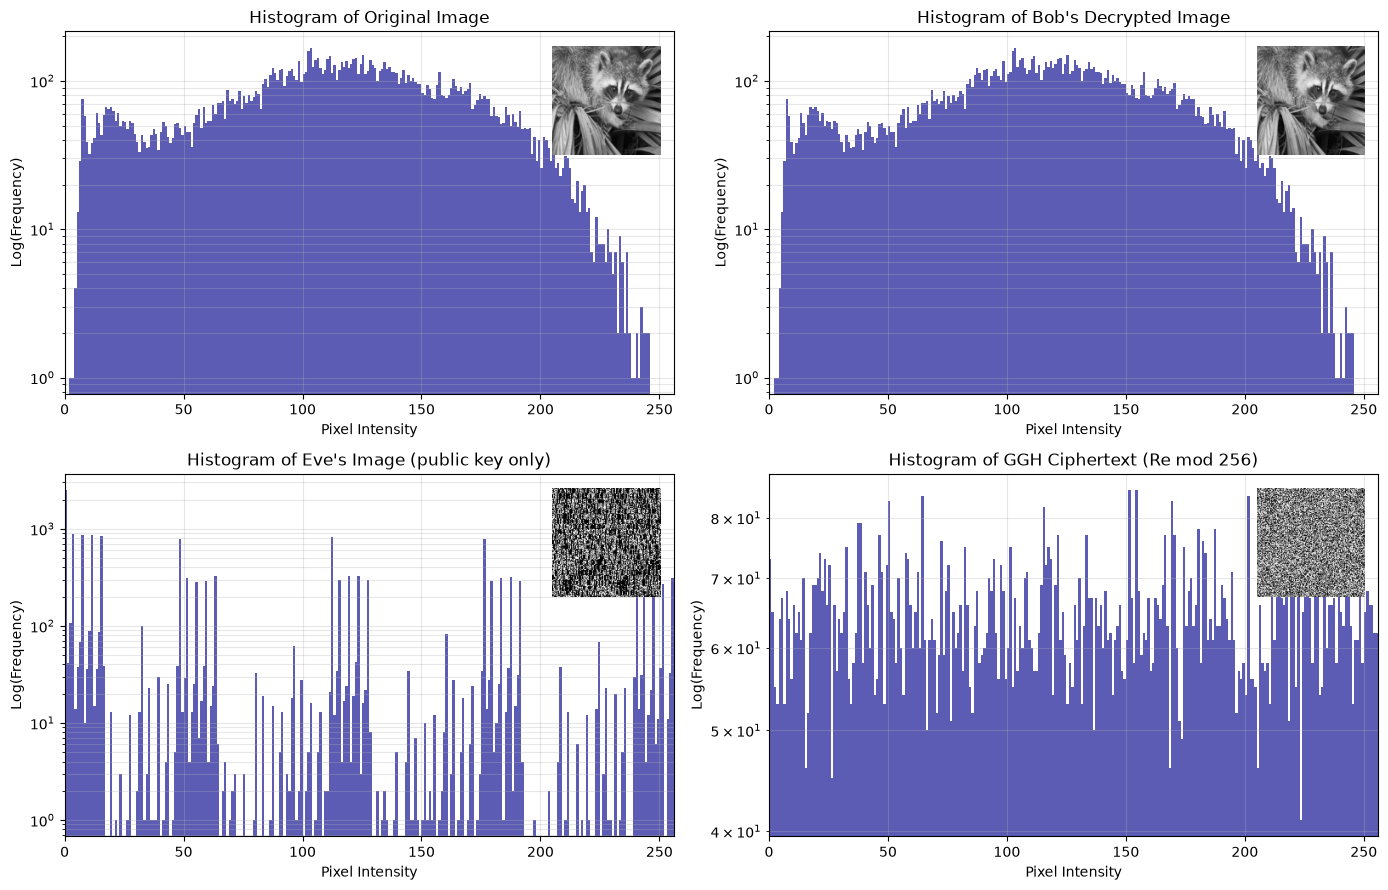

Image                                   Mean    Variance   Entropy
------------------------------------------------------------------
Original Image                        113.48      2611.1     7.635
Bob's Decrypted Image                 113.48      2611.1     7.635
Eve's Image (public key only)          90.24      7833.8     5.229
GGH Ciphertext (Re mod 256)           127.58      5450.3     7.989

Ciphertext real-part range (before mod 256): -2.788e+07 to 2.573e+07


In [85]:
# ============================================================
# Pixel histograms + stats table (Shankar & Mishra, Fig. 3-5 / Table II style)
# Run AFTER the image transmission cell.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

def entropy8(a):
    """Shannon entropy of an 8-bit image (ideal = 8 bits)."""
    counts = np.bincount(np.asarray(a, dtype=np.uint8).ravel(), minlength=256)
    p = counts[counts > 0] / counts.sum()
    return float(-(p * np.log2(p)).sum())

# --- Ciphertext as a "pixel image" -------------------------------------------
# GGH ciphertext values are huge and not reduced mod q, so (like Shankar's mod-q
# encrypted image) we show Re(ciphertext) mod 256 for visualisation only.
with torch.no_grad():
    eng = bob_model._lattice_engine
    x = bob_model._mapper(b_input.to(torch.float64)).to(torch.complex128)
    x = x.reshape(-1, bob_model._lattice_n)
    eng.B = eng.B.to(device=x.device, dtype=torch.complex128)
    qs = 10 ** 0.5
    c = eng.encrypt(x * qs)                      # ciphertext in the lattice domain
c_real = c.real.flatten().cpu().numpy()
cipher_img = (np.round(c_real[:res * res]) % 256).astype(np.uint8).reshape(res, res)

# --- Histograms ----------------------------------------------------------------
panels = [
    ("Histogram of Original Image",                 img_resized),
    ("Histogram of Bob's Decrypted Image",          bob_res),
    ("Histogram of Eve's Image (public key only)",  eve_res),
    ("Histogram of GGH Ciphertext (Re mod 256)",    cipher_img),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (title, im) in zip(axes.ravel(), panels):
    ax.hist(np.asarray(im).ravel(), bins=256, range=(0, 256),
            color="#3F3FA8", alpha=0.85, edgecolor="none")
    ax.set_yscale("log")
    ax.set_xlim(0, 256)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Pixel Intensity")
    ax.set_ylabel("Log(Frequency)")
    ax.grid(True, which="both", alpha=0.3)
    inset = ax.inset_axes([0.80, 0.66, 0.18, 0.30])   # thumbnail, top-right
    inset.imshow(im, cmap="gray", vmin=0, vmax=255)
    inset.axis("off")
plt.tight_layout()
plt.show()

# --- Stats table (like Shankar & Mishra Table II) -------------------------------
print(f"{'Image':34s}{'Mean':>10s}{'Variance':>12s}{'Entropy':>10s}")
print("-" * 66)
for title, im in panels:
    a = np.asarray(im, dtype=np.float64)
    name = title.replace("Histogram of ", "")
    print(f"{name:34s}{a.mean():10.2f}{a.var():12.1f}{entropy8(im):10.3f}")
print(f"\nCiphertext real-part range (before mod 256): "
      f"{c_real.min():.3e} to {c_real.max():.3e}")